<a href="https://colab.research.google.com/github/SUDEEPZ-RAM/Classification-of-speech-categories-from-1-bit-quantized-signals/blob/main/1D_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 16bit

In [81]:
import os
import time
import random
import hashlib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("GPU :", tf.config.list_physical_devices("GPU"))

class_names = ["Command", "Conversation", "Numeric", "Read"]

TensorFlow : 2.20.0
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [82]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal

WEIGHT_DECAY = 5e-4

def build_cnn1d_m5(input_shape=(16000,1), num_classes=4, dropout_rate=0.4):
    inputs = Input(shape=input_shape, name="waveform")

    x = layers.Conv1D(128, 80, strides=4, padding="same", use_bias=False,
        kernel_initializer=HeNormal(), kernel_regularizer=l2(WEIGHT_DECAY))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(4, strides=4)(x)

    x = layers.Conv1D(128, 3, padding="same", use_bias=False,
        kernel_initializer=HeNormal(), kernel_regularizer=l2(WEIGHT_DECAY))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(4, strides=4)(x)

    x = layers.Conv1D(256, 3, padding="same", use_bias=False,
        kernel_initializer=HeNormal(), kernel_regularizer=l2(WEIGHT_DECAY))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(4, strides=4)(x)

    x = layers.Conv1D(512, 3, padding="same", use_bias=False,
        kernel_initializer=HeNormal(), kernel_regularizer=l2(WEIGHT_DECAY))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    return Model(inputs, outputs, name="CNN1D_M5")

In [83]:
def arr_hash(a):
    return hashlib.md5(np.ascontiguousarray(a).tobytes()).hexdigest()

def dataset_report(name, X_tr, X_v, X_te, y_tr, y_v, y_te):
    print("="*70)
    print(f"DATASET REPORT: {name}")
    print("="*70)
    print(f"X_train shape: {X_tr.shape}, dtype: {X_tr.dtype}")
    print(f"X_val   shape: {X_v.shape}, dtype: {X_v.dtype}")
    print(f"X_test  shape: {X_te.shape}, dtype: {X_te.dtype}")

    sample = X_tr[:200]
    uniq = np.unique(sample)
    print(f"Min value: {X_tr.min():.6f}  |  Max value: {X_tr.max():.6f}")
    print(f"Num unique values (sample of 200): {len(uniq)}")
    if len(uniq) <= 10:
        print(f"Unique values: {uniq}")

    print(f"\nMD5(X_train): {arr_hash(X_tr)}")
    print(f"MD5(X_val):   {arr_hash(X_v)}")
    print(f"MD5(X_test):  {arr_hash(X_te)}")

    for split_name, y in [("train", y_tr), ("val", y_v), ("test", y_te)]:
        vals, counts = np.unique(y, return_counts=True)
        print(f"Class distribution ({split_name}): {dict(zip(vals.tolist(), counts.tolist()))}")

    def overlap_count(A, B, n_check=500):
        idxA = np.random.choice(len(A), min(n_check, len(A)), replace=False)
        idxB = np.random.choice(len(B), min(n_check, len(B)), replace=False)
        hashesA = {hashlib.md5(A[i].tobytes()).hexdigest() for i in idxA}
        hashesB = {hashlib.md5(B[i].tobytes()).hexdigest() for i in idxB}
        return len(hashesA & hashesB)

    print(f"\nSampled train/val overlap: {overlap_count(X_tr, X_v)}")
    print(f"Sampled train/test overlap: {overlap_count(X_tr, X_te)}")
    print("="*70)

def architecture_report(model):
    print("="*70)
    print(f"MODEL: {model.name}")
    print("="*70)
    rows = []
    for layer in model.layers:
        params = layer.count_params()
        try:
            out_shape = layer.output_shape
        except AttributeError:
            out_shape = "N/A"
        rows.append({"Layer": layer.name, "Type": layer.__class__.__name__,
                      "Output Shape": str(out_shape), "Params": params})
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    total = model.count_params()
    trainable = sum(w.numpy().size for w in model.trainable_weights)
    print(f"\nTotal Parameters: {total:,}")
    print(f"Trainable: {trainable:,}  |  Non-trainable: {total - trainable:,}")
    print("="*70)

def compare_datasets(X_a, name_a, X_b, name_b, n_check=300):
    n = min(len(X_a), len(X_b), n_check)
    idx = np.random.choice(min(len(X_a), len(X_b)), n, replace=False)
    identical = sum(
        1 for i in idx
        if X_a[i].shape == X_b[i].shape and np.array_equal(X_a[i], X_b[i])
    )
    print(f"{name_a} vs {name_b}: {identical}/{n} identical rows sampled")
    print(f"{name_a} range: [{X_a.min():.4f}, {X_a.max():.4f}]")
    print(f"{name_b} range: [{X_b.min():.4f}, {X_b.max():.4f}]")

In [84]:
import zipfile

zip_path = "/content/drive/MyDrive/1bit_speech/preprocessed/preprocessed_16bit.zip"
extract_path = "/content/drive/MyDrive/1bit_speech/preprocessed"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("16-bit extraction completed!")

16-bit extraction completed!


In [85]:
for f in sorted(os.listdir(extract_path)):
    print(f)

X_1bit_test.npy
X_1bit_train.npy
X_1bit_val.npy
X_test.npy
X_train.npy
X_val.npy
preprocessed_16bit.zip
preprocessed_1bit.zip
y_1bit_test.npy
y_1bit_train.npy
y_1bit_val.npy
y_test.npy
y_train.npy
y_val.npy


In [86]:
DATA_PATH = "/content/drive/MyDrive/1bit_speech/preprocessed"

X_train = np.load(os.path.join(DATA_PATH, "X_train.npy"))
X_val   = np.load(os.path.join(DATA_PATH, "X_val.npy"))
X_test  = np.load(os.path.join(DATA_PATH, "X_test.npy"))

y_train = np.load(os.path.join(DATA_PATH, "y_train.npy"))
y_val   = np.load(os.path.join(DATA_PATH, "y_val.npy"))
y_test  = np.load(os.path.join(DATA_PATH, "y_test.npy"))

print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)

Train : (9600, 16000, 1)
Val   : (1200, 16000, 1)
Test  : (1200, 16000, 1)


In [87]:
dataset_report("16-bit", X_train, X_val, X_test, y_train, y_val, y_test)

DATASET REPORT: 16-bit
X_train shape: (9600, 16000, 1), dtype: float32
X_val   shape: (1200, 16000, 1), dtype: float32
X_test  shape: (1200, 16000, 1), dtype: float32
Min value: -1.000000  |  Max value: 1.000000
Num unique values (sample of 200): 1574013

MD5(X_train): e345e0a6dc0050bccee60268b68e2b85
MD5(X_val):   38c5ed89db441555378acd3ea0e6d095
MD5(X_test):  4b3ae8ba263e3bbcc601d76e74538e05
Class distribution (train): {0: 2400, 1: 2400, 2: 2400, 3: 2400}
Class distribution (val): {0: 300, 1: 300, 2: 300, 3: 300}
Class distribution (test): {0: 300, 1: 300, 2: 300, 3: 300}

Sampled train/val overlap: 0
Sampled train/test overlap: 0


In [88]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def augment_16bit(x, y):
    gain = tf.random.uniform([], 0.8, 1.2)
    x = x * gain
    noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=0.01)
    x = x + noise
    shift = tf.random.uniform([], -800, 800, dtype=tf.int32)
    x = tf.roll(x, shift=shift, axis=0)
    return x, y

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(2000, seed=SEED)
            .map(augment_16bit, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE).prefetch(AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
           .batch(BATCH_SIZE).prefetch(AUTOTUNE))

In [90]:
tf.keras.backend.clear_session()

model_16bit = build_cnn1d_m5(input_shape=(16000,1), num_classes=4)

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)

model_16bit.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

model_16bit.summary()
architecture_report(model_16bit)

Model: "CNN1D_M5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ waveform (InputLayer)           │ (None, 16000, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4000, 128)      │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 4000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1000, 128)      │        49,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 250, 256)       │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 250, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 250, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 62, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 62, 512)        │       393,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 62, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 62, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,060 (2.13 MB)

 Trainable params: 555,012 (2.12 MB)

 Non-trainable params: 2,048 (8.00 KB)

MODEL: CNN1D_M5
                   Layer                   Type Output Shape  Params
                waveform             InputLayer          N/A       0
                  conv1d                 Conv1D          N/A   10240
     batch_normalization     BatchNormalization          N/A     512
                   re_lu                   ReLU          N/A       0
           max_pooling1d           MaxPooling1D          N/A       0
                conv1d_1                 Conv1D          N/A   49152
   batch_normalization_1     BatchNormalization          N/A     512
                 re_lu_1                   ReLU          N/A       0
         max_pooling1d_1           MaxPooling1D          N/A       0
                conv1d_2                 Conv1D          N/A   98304
   batch_normalization_2     BatchNormalization          N/A    1024
                 re_lu_2                   ReLU          N/A       0
         max_pooling1d_2           MaxPooling1D          N/A       0
                co

In [91]:
SAVE_PATH_16BIT = "cnn1d_m5_16bit.keras"

callbacks_16bit = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=SAVE_PATH_16BIT, monitor="val_accuracy",
        save_best_only=True, mode="max", verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=6,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    )
]

In [92]:
EPOCHS = 50

start_time = time.time()

history_16bit = model_16bit.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_16bit,
    verbose=1
)

training_time_16bit = time.time() - start_time
print(f"\nTraining completed in {training_time_16bit/60:.2f} minutes")

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6573 - loss: 1.8576
Epoch 1: val_accuracy improved from None to 0.44917, saving model to cnn1d_m5_16bit.keras

Epoch 1: finished saving model to cnn1d_m5_16bit.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.7306 - loss: 1.6778 - val_accuracy: 0.4492 - val_loss: 2.2474 - learning_rate: 3.0000e-04
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8157 - loss: 1.4101
Epoch 2: val_accuracy improved from 0.44917 to 0.67333, saving model to cnn1d_m5_16bit.keras

Epoch 2: finished saving model to cnn1d_m5_16bit.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.8282 - loss: 1.3606 - val_accuracy: 0.6733 - val_loss: 1.6305 - learning_rate: 3.0000e-04
Epoch 3/50
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8511 - loss: 1.2411
Epoch 3: val_accuracy improved from 0.67333 to 0.77667, saving model to cnn1d_m5_16bit.keras

Epoch 3: finished saving model to cnn1d_m5_16bit.keras
1

In [93]:
test_loss_16bit, test_acc_16bit = model_16bit.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy : {test_acc_16bit:.4f}")
print(f"Test Loss     : {test_loss_16bit:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9525 - loss: 0.5147

Test Accuracy : 0.9525
Test Loss     : 0.5147


In [94]:
y_prob_16bit = model_16bit.predict(test_ds, verbose=1)
y_pred_16bit = np.argmax(y_prob_16bit, axis=1)
y_true_16bit = np.concatenate([y.numpy() for _, y in test_ds])

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step


In [96]:
accuracy_16bit  = accuracy_score(y_true_16bit, y_pred_16bit)
precision_16bit = precision_score(y_true_16bit, y_pred_16bit, average="macro")
recall_16bit    = recall_score(y_true_16bit, y_pred_16bit, average="macro")
f1_16bit        = f1_score(y_true_16bit, y_pred_16bit, average="macro")
roc_auc_16bit   = roc_auc_score(tf.keras.utils.to_categorical(y_true_16bit,4),
                                 y_prob_16bit, multi_class="ovr")

print("="*50)
print("Accuracy :", accuracy_16bit)
print("Precision:", precision_16bit)
print("Recall   :", recall_16bit)
print("F1 Score :", f1_16bit)
print("ROC AUC  :", roc_auc_16bit)
print("="*50)

Accuracy : 0.9525
Precision: 0.9525348082554856
Recall   : 0.9525
F1 Score : 0.9523705061034015
ROC AUC  : 0.9951157407407407


In [97]:
print(classification_report(y_true_16bit, y_pred_16bit, target_names=class_names, digits=4))

              precision    recall  f1-score   support

     Command     0.9322    0.9167    0.9244       300
Conversation     0.9865    0.9733    0.9799       300
     Numeric     0.9489    0.9900    0.9690       300
        Read     0.9426    0.9300    0.9362       300

    accuracy                         0.9525      1200
   macro avg     0.9525    0.9525    0.9524      1200
weighted avg     0.9525    0.9525    0.9524      1200



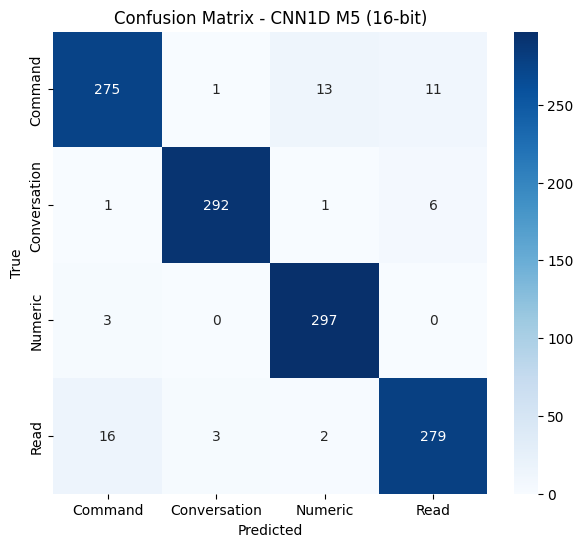

In [98]:
cm_16bit = confusion_matrix(y_true_16bit, y_pred_16bit)

plt.figure(figsize=(7,6))
sns.heatmap(cm_16bit, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix - CNN1D M5 (16-bit)")
plt.show()

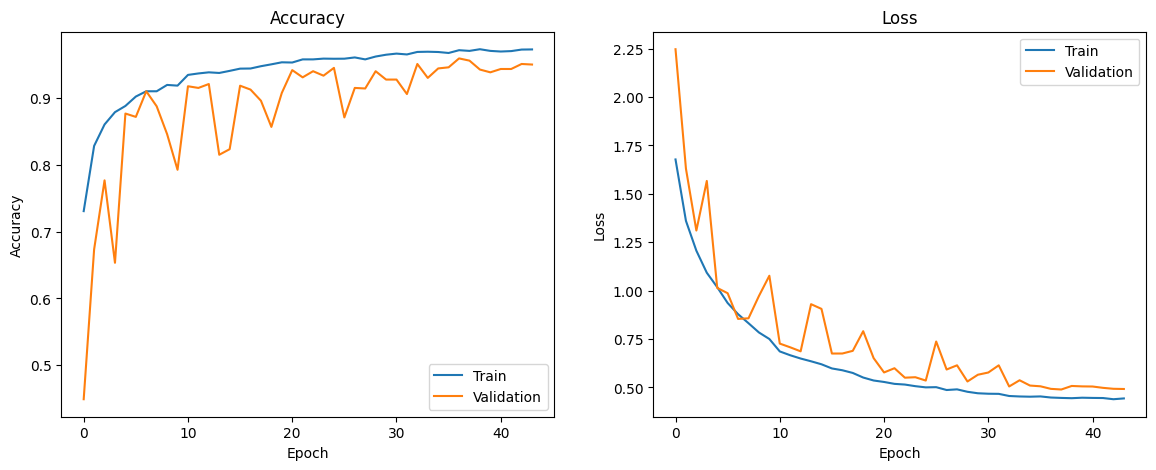

In [99]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_16bit.history["accuracy"], label="Train")
plt.plot(history_16bit.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_16bit.history["loss"], label="Train")
plt.plot(history_16bit.history["val_loss"], label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss"); plt.legend()

plt.show()

In [100]:
print("="*60)
print("Final Training Accuracy :", history_16bit.history["accuracy"][-1])
print("Final Validation Accuracy :", history_16bit.history["val_accuracy"][-1])
print()
print("Final Training Loss :", history_16bit.history["loss"][-1])
print("Final Validation Loss :", history_16bit.history["val_loss"][-1])
print()
print("Best Validation Accuracy :", max(history_16bit.history["val_accuracy"]))
print()
print(f"Training Time : {training_time_16bit/60:.2f} minutes")
print()
print("Total Parameters :", model_16bit.count_params())
print("="*60)

results_16bit = {
    "Architecture": "CNN1D_M5", "Bit-depth": "16-bit",
    "Train Accuracy": history_16bit.history["accuracy"][-1],
    "Validation Accuracy": history_16bit.history["val_accuracy"][-1],
    "Best Validation Accuracy": max(history_16bit.history["val_accuracy"]),
    "Test Accuracy": accuracy_16bit, "Precision": precision_16bit,
    "Recall": recall_16bit, "F1 Score": f1_16bit, "ROC AUC": roc_auc_16bit,
    "Parameters": model_16bit.count_params(),
    "Training Time (min)": training_time_16bit / 60
}

results_df_16bit = pd.DataFrame([results_16bit])
results_df_16bit

Final Training Accuracy : 0.9726041555404663
Final Validation Accuracy : 0.949999988079071

Final Training Loss : 0.4429723620414734
Final Validation Loss : 0.49174371361732483

Best Validation Accuracy : 0.9591666460037231

Training Time : 5.72 minutes

Total Parameters : 557060


,Architecture,Bit-depth,Train Accuracy,Validation Accuracy,Best Validation Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC,Parameters,Training Time (min)
0,CNN1D_M5,16-bit,0.972604,0.95,0.959167,0.9525,0.952535,0.9525,0.952371,0.995116,557060,5.723472


# 1bit

In [104]:
zip_path = "/content/drive/MyDrive/1bit_speech/preprocessed/preprocessed_1bit.zip"
extract_path_1bit = "/content/preprocessed_1bit"
os.makedirs(extract_path_1bit, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path_1bit)

print("1-bit extraction completed!")

1-bit extraction completed!


In [120]:
for f in sorted(os.listdir(extract_path_1bit)):
    print(f)

X_1bit_test.npy
X_1bit_train.npy
X_1bit_val.npy
y_1bit_test.npy
y_1bit_train.npy
y_1bit_val.npy


In [106]:
X_1_train = np.load(os.path.join(extract_path_1bit, "X_1bit_train.npy"))
X_1_val   = np.load(os.path.join(extract_path_1bit, "X_1bit_val.npy"))
X_1_test  = np.load(os.path.join(extract_path_1bit, "X_1bit_test.npy"))

y_1_train = np.load(os.path.join(extract_path_1bit, "y_1bit_train.npy"))
y_1_val   = np.load(os.path.join(extract_path_1bit, "y_1bit_val.npy"))
y_1_test  = np.load(os.path.join(extract_path_1bit, "y_1bit_test.npy"))

X_1_train = np.squeeze(X_1_train)[..., np.newaxis]
X_1_val   = np.squeeze(X_1_val)[..., np.newaxis]
X_1_test  = np.squeeze(X_1_test)[..., np.newaxis]

print("Train :", X_1_train.shape)
print("Val   :", X_1_val.shape)
print("Test  :", X_1_test.shape)

Train : (9600, 16000, 1)
Val   : (1200, 16000, 1)
Test  : (1200, 16000, 1)


In [107]:
dataset_report("1-bit", X_1_train, X_1_val, X_1_test, y_1_train, y_1_val, y_1_test)

print("\n--- Cross-dataset comparison (16-bit vs 1-bit) ---")
compare_datasets(X_train, "16-bit", X_1_train, "1-bit")

DATASET REPORT: 1-bit
X_train shape: (9600, 16000, 1), dtype: float32
X_val   shape: (1200, 16000, 1), dtype: float32
X_test  shape: (1200, 16000, 1), dtype: float32
Min value: -1.000000  |  Max value: 1.000000
Num unique values (sample of 200): 2
Unique values: [-1.  1.]

MD5(X_train): b5d4ec3d39bcb495d17aaa30a5242fbb
MD5(X_val):   2b3e7be315e8b916e340e875e8bce15f
MD5(X_test):  95646eeacf00740a3cfb4621dd2195e8
Class distribution (train): {0: 2400, 1: 2400, 2: 2400, 3: 2400}
Class distribution (val): {0: 300, 1: 300, 2: 300, 3: 300}
Class distribution (test): {0: 300, 1: 300, 2: 300, 3: 300}

Sampled train/val overlap: 0
Sampled train/test overlap: 0

--- Cross-dataset comparison (16-bit vs 1-bit) ---
16-bit vs 1-bit: 0/300 identical rows sampled
16-bit range: [-1.0000, 1.0000]
1-bit range: [-1.0000, 1.0000]


In [108]:
def augment_1bit(x, y):
    shift = tf.random.uniform([], -800, 800, dtype=tf.int32)
    x = tf.roll(x, shift=shift, axis=0)
    return x, y

train_1bit_ds = (tf.data.Dataset.from_tensor_slices((X_1_train, y_1_train))
                 .shuffle(2000, seed=SEED)
                 .map(augment_1bit, num_parallel_calls=AUTOTUNE)
                 .batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_1bit_ds = (tf.data.Dataset.from_tensor_slices((X_1_val, y_1_val))
               .batch(BATCH_SIZE).prefetch(AUTOTUNE))

test_1bit_ds = (tf.data.Dataset.from_tensor_slices((X_1_test, y_1_test))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))

In [110]:
tf.keras.backend.clear_session()

model_1bit = build_cnn1d_m5(input_shape=(16000,1), num_classes=4)

optimizer_1bit = tf.keras.optimizers.Adam(learning_rate=3e-4)

model_1bit.compile(
    optimizer=optimizer_1bit,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model_1bit.summary()
architecture_report(model_1bit)

Model: "CNN1D_M5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ waveform (InputLayer)           │ (None, 16000, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4000, 128)      │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 4000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1000, 128)      │        49,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1000, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 1000, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 250, 256)       │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 250, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 250, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 62, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 62, 512)        │       393,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 62, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 62, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,060 (2.13 MB)

 Trainable params: 555,012 (2.12 MB)

 Non-trainable params: 2,048 (8.00 KB)

MODEL: CNN1D_M5
                   Layer                   Type Output Shape  Params
                waveform             InputLayer          N/A       0
                  conv1d                 Conv1D          N/A   10240
     batch_normalization     BatchNormalization          N/A     512
                   re_lu                   ReLU          N/A       0
           max_pooling1d           MaxPooling1D          N/A       0
                conv1d_1                 Conv1D          N/A   49152
   batch_normalization_1     BatchNormalization          N/A     512
                 re_lu_1                   ReLU          N/A       0
         max_pooling1d_1           MaxPooling1D          N/A       0
                conv1d_2                 Conv1D          N/A   98304
   batch_normalization_2     BatchNormalization          N/A    1024
                 re_lu_2                   ReLU          N/A       0
         max_pooling1d_2           MaxPooling1D          N/A       0
                co

In [111]:
SAVE_PATH_1BIT = "cnn1d_m5_1bit.keras"

callbacks_1bit = [
    tf.keras.callbacks.ModelCheckpoint(
        SAVE_PATH_1BIT, monitor="val_accuracy",
        save_best_only=True, mode="max", verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=6,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    )
]

In [112]:
EPOCHS = 50

start_1bit = time.time()

history_1bit = model_1bit.fit(
    train_1bit_ds,
    validation_data=val_1bit_ds,
    epochs=EPOCHS,
    callbacks=callbacks_1bit,
    verbose=1
)

training_time_1bit = time.time() - start_1bit
print(f"\nTraining Time : {training_time_1bit/60:.2f} minutes")

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6663 - loss: 1.8102
Epoch 1: val_accuracy improved from None to 0.31083, saving model to cnn1d_m5_1bit.keras

Epoch 1: finished saving model to cnn1d_m5_1bit.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.7289 - loss: 1.6604 - val_accuracy: 0.3108 - val_loss: 4.7867 - learning_rate: 3.0000e-04
Epoch 2/50
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7935 - loss: 1.4609
Epoch 2: val_accuracy improved from 0.31083 to 0.68083, saving model to cnn1d_m5_1bit.keras

Epoch 2: finished saving model to cnn1d_m5_1bit.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8134 - loss: 1.4003 - val_accuracy: 0.6808 - val_loss: 2.0766 - learning_rate: 3.0000e-04
Epoch 3/50
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8326 - loss: 1.3052
Epoch 3: val_accuracy improved from 0.68083 to 0.75333, saving model to cnn1d_m5_1bit.keras

Epoch 3: finished saving model to cnn1d_m5_1bit.keras
150/150 

In [113]:
test_loss_1bit, test_acc_1bit = model_1bit.evaluate(test_1bit_ds, verbose=1)
print(f"\nTest Accuracy : {test_acc_1bit:.4f}")
print(f"Test Loss     : {test_loss_1bit:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9408 - loss: 0.5425

Test Accuracy : 0.9408
Test Loss     : 0.5425


In [114]:
y_prob_1bit = model_1bit.predict(test_1bit_ds, verbose=1)
y_pred_1bit = np.argmax(y_prob_1bit, axis=1)
y_true_1bit = np.concatenate([y.numpy() for _, y in test_1bit_ds])

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step


In [115]:
accuracy_1bit  = accuracy_score(y_true_1bit, y_pred_1bit)
precision_1bit = precision_score(y_true_1bit, y_pred_1bit, average="macro")
recall_1bit    = recall_score(y_true_1bit, y_pred_1bit, average="macro")
f1_1bit        = f1_score(y_true_1bit, y_pred_1bit, average="macro")
roc_auc_1bit   = roc_auc_score(tf.keras.utils.to_categorical(y_true_1bit,4),
                                y_prob_1bit, multi_class="ovr")

print("="*50)
print("Accuracy :", accuracy_1bit)
print("Precision:", precision_1bit)
print("Recall   :", recall_1bit)
print("F1 Score :", f1_1bit)
print("ROC AUC  :", roc_auc_1bit)
print("="*50)

Accuracy : 0.9408333333333333
Precision: 0.9413095602648385
Recall   : 0.9408333333333333
F1 Score : 0.940979138773846
ROC AUC  : 0.9925351851851854


In [116]:
print(classification_report(y_true_1bit, y_pred_1bit, target_names=class_names, digits=4))

              precision    recall  f1-score   support

     Command     0.9220    0.9067    0.9143       300
Conversation     0.9762    0.9567    0.9663       300
     Numeric     0.9868    0.9933    0.9900       300
        Read     0.8803    0.9067    0.8933       300

    accuracy                         0.9408      1200
   macro avg     0.9413    0.9408    0.9410      1200
weighted avg     0.9413    0.9408    0.9410      1200



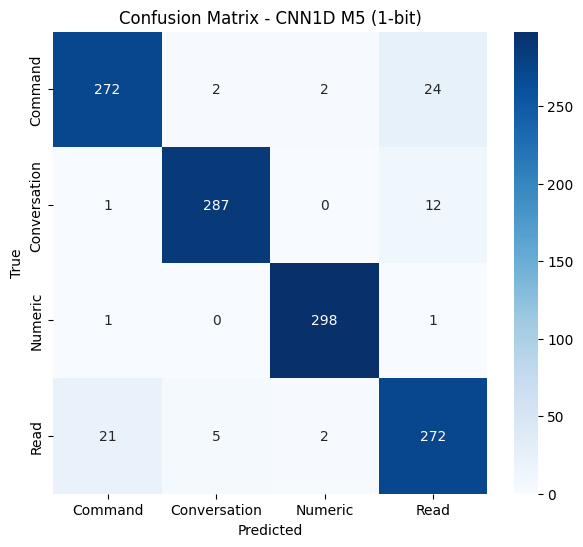

In [117]:
cm_1bit = confusion_matrix(y_true_1bit, y_pred_1bit)

plt.figure(figsize=(7,6))
sns.heatmap(cm_1bit, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix - CNN1D M5 (1-bit)")
plt.show()

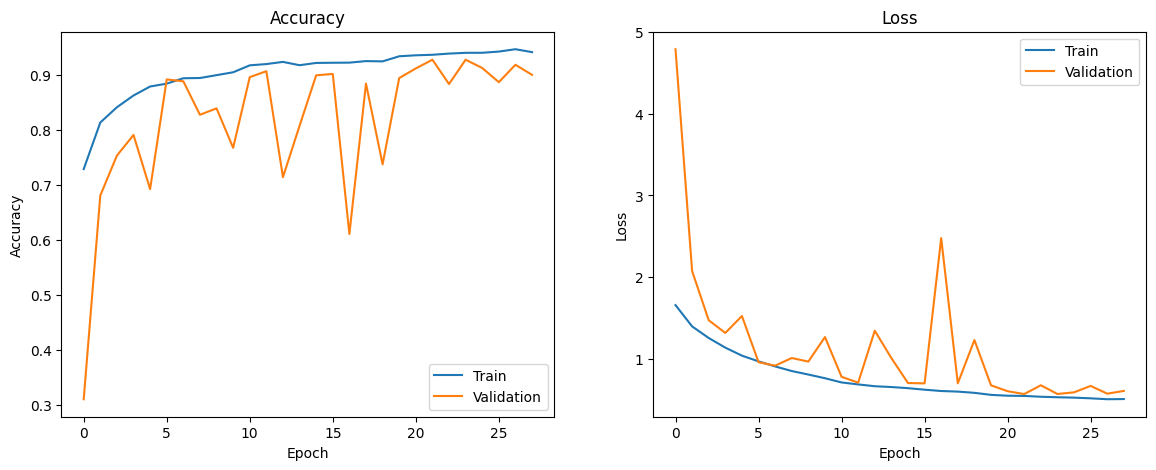

In [118]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_1bit.history["accuracy"], label="Train")
plt.plot(history_1bit.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_1bit.history["loss"], label="Train")
plt.plot(history_1bit.history["val_loss"], label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss"); plt.legend()

plt.show()

In [119]:
results_1bit = {
    "Architecture": "CNN1D_M5", "Bit-depth": "1-bit",
    "Train Accuracy": history_1bit.history["accuracy"][-1],
    "Validation Accuracy": history_1bit.history["val_accuracy"][-1],
    "Best Validation Accuracy": max(history_1bit.history["val_accuracy"]),
    "Test Accuracy": accuracy_1bit, "Precision": precision_1bit,
    "Recall": recall_1bit, "F1 Score": f1_1bit, "ROC AUC": roc_auc_1bit,
    "Parameters": model_1bit.count_params(),
    "Training Time (min)": training_time_1bit / 60
}

results_df_1bit = pd.DataFrame([results_1bit])

# Combined comparison table -- side by side for your professor
final_comparison = pd.concat([results_df_16bit, results_df_1bit], ignore_index=True)
final_comparison

,Architecture,Bit-depth,Train Accuracy,Validation Accuracy,Best Validation Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC,Parameters,Training Time (min)
0,CNN1D_M5,16-bit,0.972604,0.95,0.959167,0.952500,0.952535,0.952500,0.952371,0.995116,557060,5.723472
1,CNN1D_M5,1-bit,0.941250,0.90,0.927500,0.940833,0.941310,0.940833,0.940979,0.992535,557060,2.896128


In [121]:
!git config --global user.email "sudeepmanchikanti123@gmail.com"
!git config --global user.name "SUDEEPZ-RAM"


In [122]:
!git init
!echo "# Classification-of-speech-categories-from-1-bit-quantized-signals" >> README.md


hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [123]:
!git add README.md
!git commit -m "first commit"


[master (root-commit) 89fa8ba] first commit
 1 file changed, 1 insertion(+)
 create mode 100644 README.md


In [124]:
!git branch -M main


In [135]:
!git remote rm origin
